## Minimal example of calculating NPQ-corrected fluorescence from float data

This notebook defines the function for calculating NPQ-corrected fluorescence from uncalibrated float `CHLA_FLUORESCENCE`, and applies it to some data from float ID 2903884 in the equatorial Pacific.

### Import packages, define function, read in float data

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from scripts.npqc import calculate_NPQ_fluo
from scripts.par15 import par15
from scripts.mld_calculator import mld_calc

In [4]:
ds = xr.open_dataset('1902593_Sprof_BGCArgoPlus.nc')

### Calculate and plot for the first 10 profiles

In [5]:
ds = par15(ds).rename({'par_15_pressure': 'par_depth'})
ds = mld_calc(ds)

In [6]:
ds = ds#.isel(N_PROF=slice(30))
ds = ds.dropna(dim='N_PROF', subset=['par_depth', 'ml_depth'])
ds = calculate_NPQ_fluo(ds)

In [52]:
ds

<xarray.Dataset> Size: 58MB
Dimensions:                                            (N_PROF: 64,
                                                        N_PARAM: 15,
                                                        N_CALIB: 1,
                                                        N_LEVELS: 1499)
Coordinates:
    JULD                                               (N_PROF) datetime64[ns] 512B ...
    LATITUDE                                           (N_PROF) float64 512B ...
    LONGITUDE                                          (N_PROF) float64 512B ...
    PRES_ADJUSTED_BGCArgoPlus                          (N_PROF, N_LEVELS) float32 384kB ...
  * N_LEVELS                                           (N_LEVELS) int64 12kB ...
  * N_PROF                                             (N_PROF) int64 512B 1 ...
Dimensions without coordinates: N_PARAM, N_CALIB
Data variables: (12/194)
    DATA_TYPE                                          object 8B ...
    FORMAT_VERSION                                     object 8B ...
    HANDBOOK_VERSION                                   object 8B ...
    REFERENCE_DATE_TIME                                object 8B ...
    DATE_CREATION                                      object 8B ...
    DATE_UPDATE                                        object 8B ...
    ...                                                 ...
    DOXY_SAT                                           (N_PROF, N_LEVELS) float64 767kB ...
    par_depth                                          (N_PROF) float64 512B ...
    ml_depth                                           (N_PROF) float64 512B ...
    NPQ_depth                                          (N_PROF) float64 512B ...
    fluo_smooth                                        (N_PROF, N_LEVELS) float32 384kB ...
    fluo_npqc                                          (N_PROF, N_LEVELS) float32 384kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-21T07:11:50Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

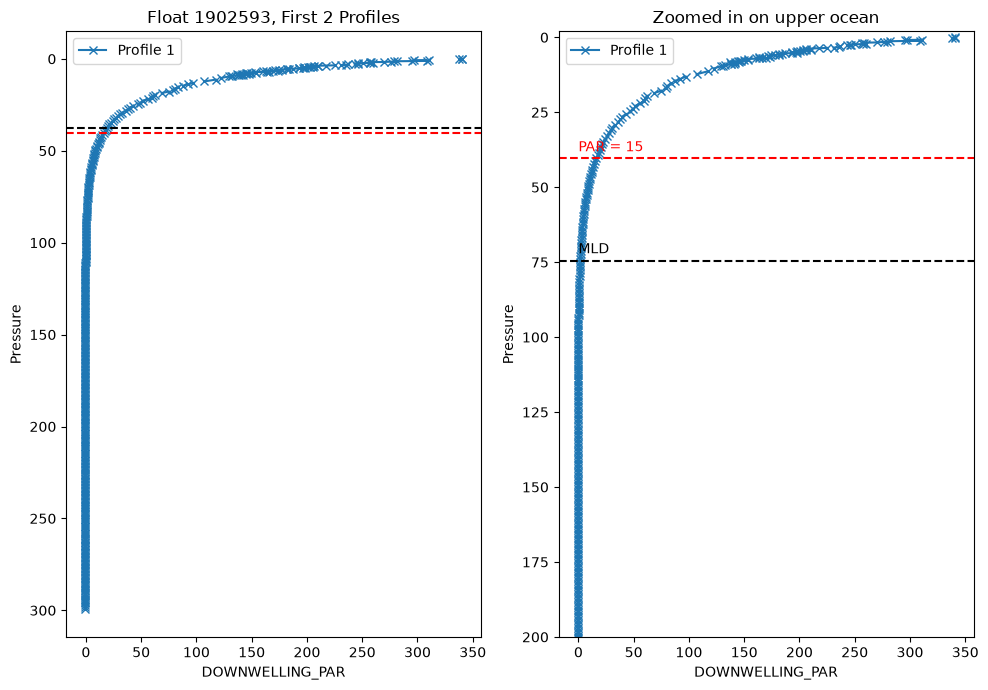

In [53]:
var_choice = 'DOWNWELLING_PAR'

fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# We can plot the first X profiles to get a look at the data:
profiles = 2
ax1.plot(ds[var_choice][7], ds['PRES'][7], marker='x', label=f'Profile {p+1}')
ax1.axhline(ds['par_depth'][7], linestyle='--', color = 'red')
ax1.axhline(ds['ml_depth'][7], linestyle='--', color = 'black')

ax2.plot(ds[var_choice][7], ds['PRES'][7], marker='x', label=f'Profile {p+1}')
ax2.axhline(ds['par_depth'][7], linestyle='--', color = 'red')
ax2.text(0, 38, 'PAR = 15 ', color='red')
ax2.axhline(ds['ml_depth'][0], linestyle='--', color = 'black')
ax2.text(0, 72, 'MLD', color='black')
#ax1.invert_yaxis()
ax1.set_xlabel(var_choice)
ax1.set_ylabel('Pressure')
ax1.legend()
ax1.set_title(f'Float {ds['WMO_ID'].values}, First {profiles} Profiles')
# our second axis is zoomed in to the upper 250m
ax1.invert_yaxis()
ax2.invert_yaxis()
ax2.set_xlabel(var_choice)
ax2.set_ylabel('Pressure')
ax2.legend()
ax2.set_title('Zoomed in on upper ocean')
max_pres = 200
ax2.set_ylim(max_pres, -2)
plt.tight_layout()

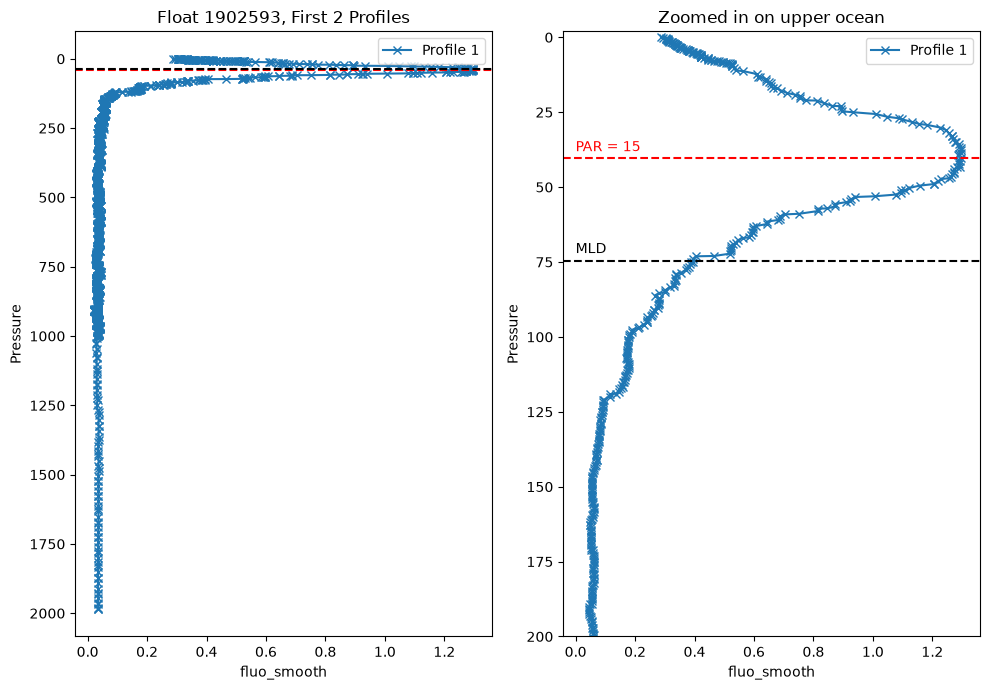

In [54]:
var_choice = 'fluo_smooth'

fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# We can plot the first X profiles to get a look at the data:
profiles = 2
ax1.plot(ds[var_choice][7], ds['PRES'][7], marker='x', label=f'Profile {p+1}')
ax1.axhline(ds['par_depth'][7], linestyle='--', color = 'red')
ax1.axhline(ds['ml_depth'][7], linestyle='--', color = 'black')

ax2.plot(ds[var_choice][7], ds['PRES'][7], marker='x', label=f'Profile {p+1}')
ax2.axhline(ds['par_depth'][7], linestyle='--', color = 'red')
ax2.text(0, 38, 'PAR = 15 ', color='red')
ax2.axhline(ds['ml_depth'][0], linestyle='--', color = 'black')
ax2.text(0, 72, 'MLD', color='black')
#ax1.invert_yaxis()
ax1.set_xlabel(var_choice)
ax1.set_ylabel('Pressure')
ax1.legend()
ax1.set_title(f'Float {ds['WMO_ID'].values}, First {profiles} Profiles')
# our second axis is zoomed in to the upper 250m
ax1.invert_yaxis()
ax2.invert_yaxis()
ax2.set_xlabel(var_choice)
ax2.set_ylabel('Pressure')
ax2.legend()
ax2.set_title('Zoomed in on upper ocean')
max_pres = 200
ax2.set_ylim(max_pres, -2)
plt.tight_layout()

(250.0, 0.0)

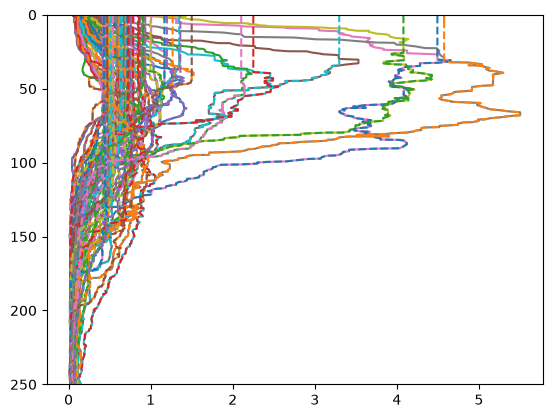

In [41]:
fig, ax = plt.subplots()
plt.plot(ds['fluo_smooth'].T, ds['PRES_ADJUSTED'].T, '-')
plt.plot(ds['fluo_npqc'].T, ds['PRES_ADJUSTED'].T, '--')
# match line colors
h1 = ax.get_children()
for hh in range(1):
    h1[hh].set_color(h1[hh-12].get_color())
ax.set_ylim([250, 0])

### Calculate NPQ
Eq. 2 from [Schallenberg et al. 2022](https://doi.org/10.1029/2021GL097616)

In [8]:
ds['NPQ'] = (ds['fluo_npqc']-ds['fluo_smooth'])/ds['fluo_smooth']

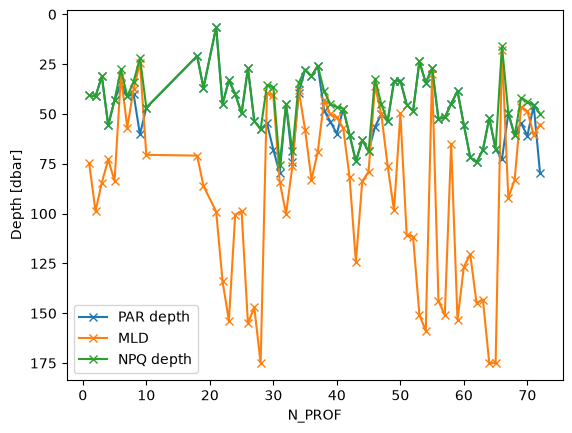

In [19]:
fig, ax = plt.subplots()
ds['par_depth'].plot.line('-x', label='PAR depth')
ds['ml_depth'].plot.line('-x', label='MLD')
ds['NPQ_depth'].plot.line('-x', label='NPQ depth')
ax.set_ylabel('Depth [dbar]')
plt.legend()
ax.set_ylim(ax.get_ylim()[::-1]);

In [ ]:
fig, ax = plt.subplots()
plt.plot(ds['fluo_smooth'].T, ds['PRES_ADJUSTED'].T, '-')
plt.plot(ds['fluo_npqc'].T, ds['PRES_ADJUSTED'].T, '--')
# match line colors
h1 = ax.get_children()
for hh in range(13, 24):
    h1[hh].set_color(h1[hh-12].get_color())
ax.set_ylim([250, 0])

# ax.axhline(0, linestyle='--')